## HEART DISEASE PREDICTION


### Stage 1 = Import Libraries

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay,precision_score,recall_score,f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

import pickle

### Stage 2 = Load Dataset

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.shape

(303, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Stage 3 : EDA

Heart Disease Distribution
target
1    165
0    138
Name: count, dtype: int64


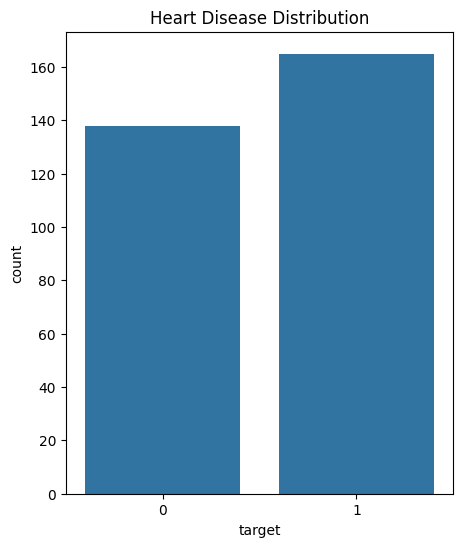

In [8]:
print("Heart Disease Distribution")
print(df['target'].value_counts())

plt.figure(figsize=(5,6))
sns.countplot(data=df , x = 'target')
plt.title('Heart Disease Distribution')
plt.show()

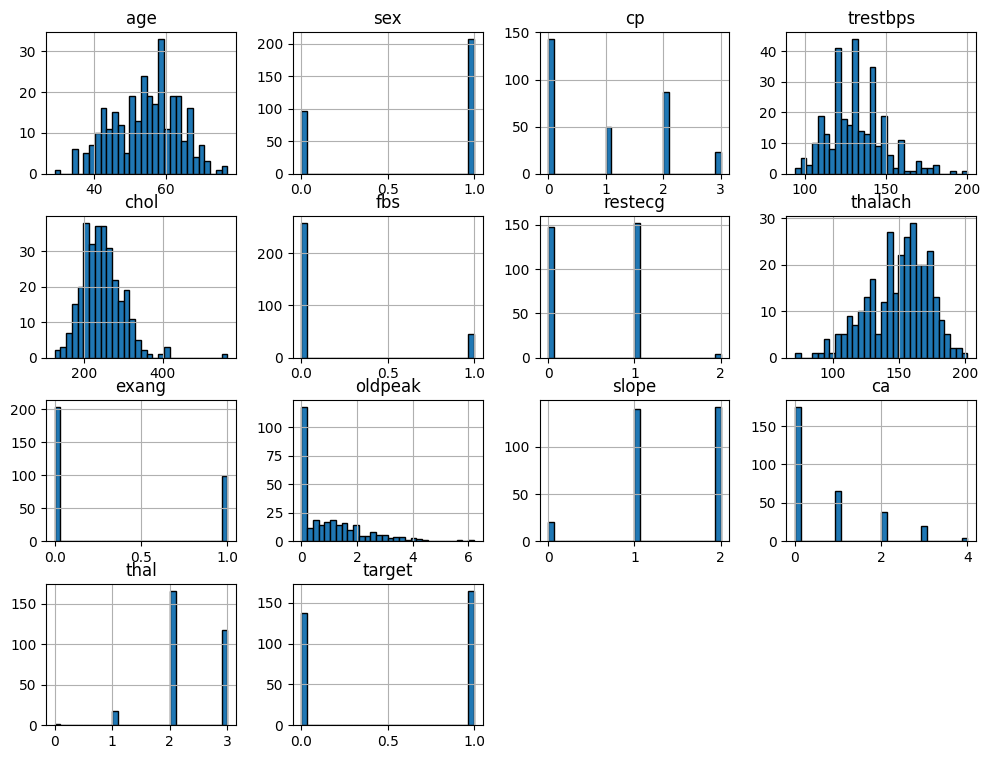

In [9]:
df.hist(figsize=(12,9),bins=30,edgecolor = 'black')
plt.title("Feature Distribution")
plt.show()

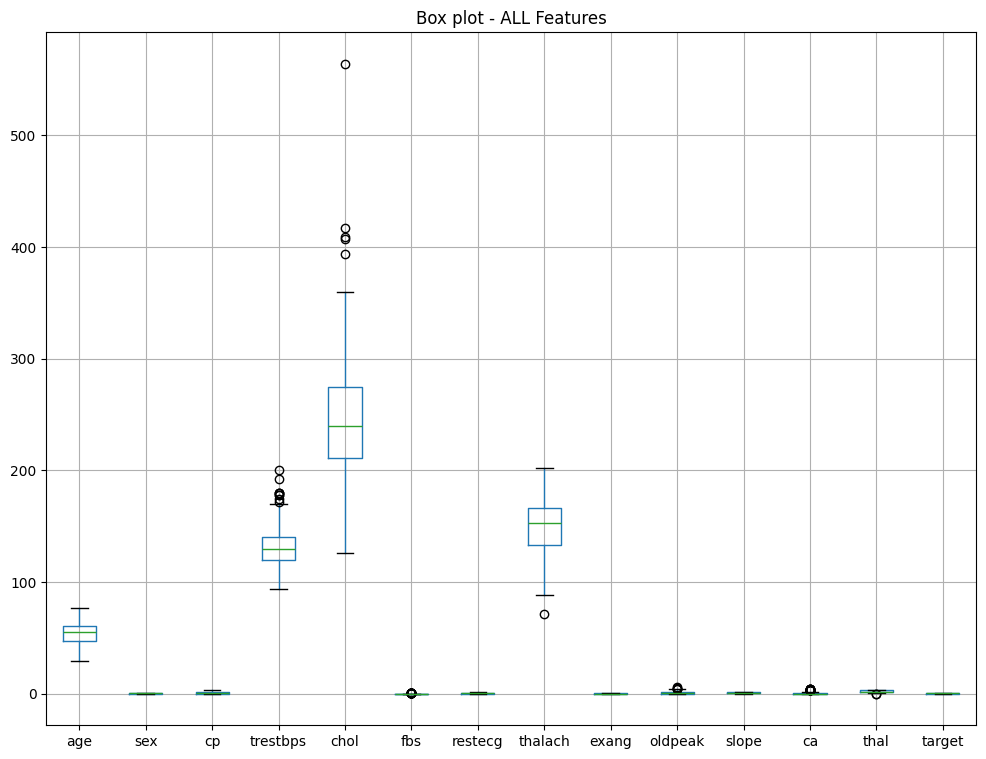

In [10]:
df.boxplot(figsize=(12,9))
plt.title("Box plot - ALL Features")
plt.show()

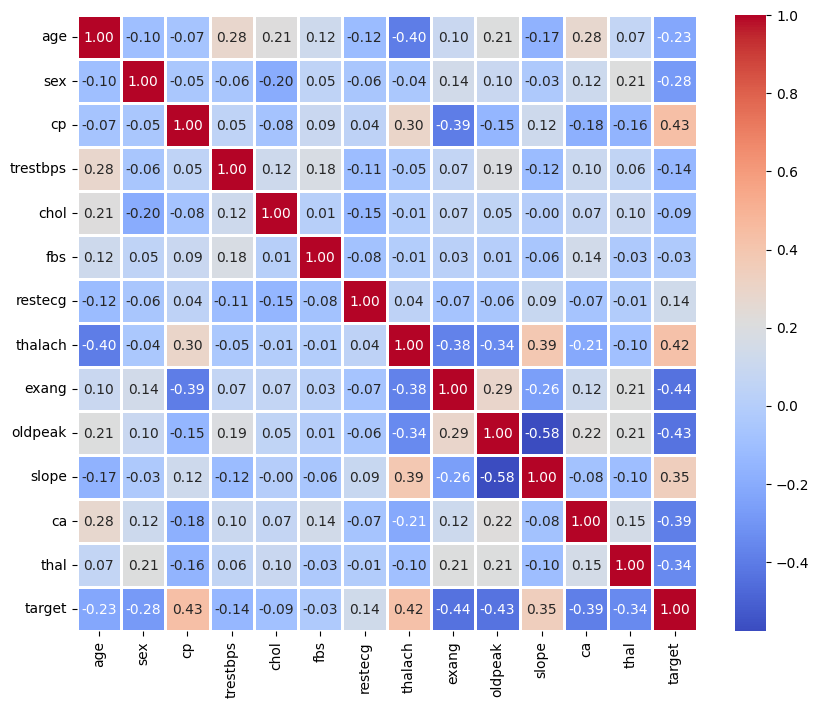

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm',linewidths=1)
plt.show()

### Stage 4 : Train Test Split

In [12]:
X = df.drop('target',axis=1)
y = df['target']

In [13]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.3 , random_state=42 , stratify=y )

### Stage 5 : Feature Scaling

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Stage 6 : Logistic Regression

In [15]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
y_predict_lr = lr.predict(X_test_scaled)

In [17]:
print("==== Logistic Regression ===")
print()
print("Accuracy Score:",round(accuracy_score(y_test,y_predict_lr)*100,2),'%')
print()
print(classification_report(y_test,y_predict_lr))

==== Logistic Regression ===

Accuracy Score: 75.82 %

              precision    recall  f1-score   support

           0       0.76      0.68      0.72        41
           1       0.76      0.82      0.79        50

    accuracy                           0.76        91
   macro avg       0.76      0.75      0.75        91
weighted avg       0.76      0.76      0.76        91



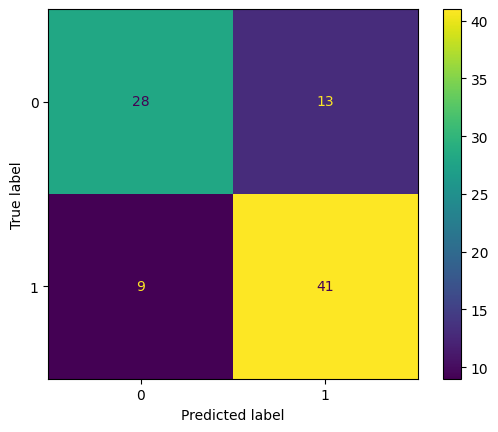

In [18]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predict_lr)
plt.show()

### Stage 7 : KNN

In [19]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
y_predict_knn = knn.predict(X_test_scaled)

In [21]:
print("==== KNN ===")
print()
print("Accuracy Score:",round(accuracy_score(y_test,y_predict_knn)*100,2),'%')
print()
print(classification_report(y_test,y_predict_knn))

==== KNN ===

Accuracy Score: 79.12 %

              precision    recall  f1-score   support

           0       0.81      0.71      0.75        41
           1       0.78      0.86      0.82        50

    accuracy                           0.79        91
   macro avg       0.79      0.78      0.79        91
weighted avg       0.79      0.79      0.79        91



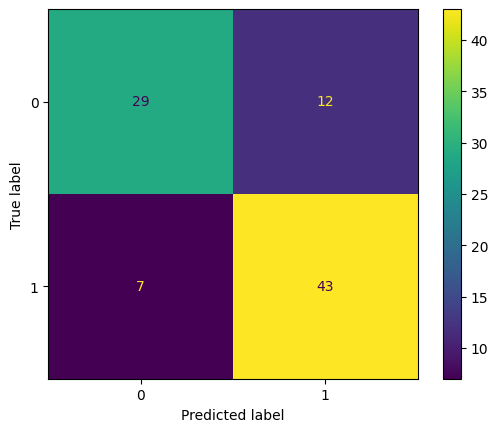

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predict_knn)
plt.show()

### Stage 8: Random Forest

In [23]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_predict_rf = rf.predict(X_test_scaled)

In [25]:
print("==== Random Forest ===")
print()
print("Accuracy Score:",round(accuracy_score(y_test,y_predict_rf)*100,2),'%')
print()
print(classification_report(y_test,y_predict_rf))

==== Random Forest ===

Accuracy Score: 79.12 %

              precision    recall  f1-score   support

           0       0.79      0.73      0.76        41
           1       0.79      0.84      0.82        50

    accuracy                           0.79        91
   macro avg       0.79      0.79      0.79        91
weighted avg       0.79      0.79      0.79        91



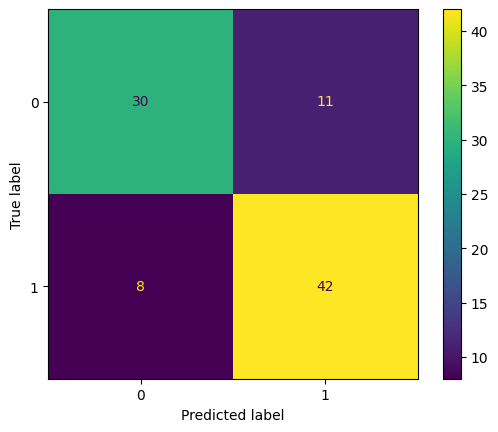

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predict_rf)
plt.show()

### Stage 9 : XG Boost

In [27]:
xgb = XGBClassifier()
xgb.fit(X_train_scaled,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
y_predict_xgb = xgb.predict(X_test_scaled)

In [29]:
print("==== XG Boost")
print()
print("Accuracy Score:",round(accuracy_score(y_test,y_predict_xgb)*100,2),'%')
print()
print(classification_report(y_test,y_predict_xgb))

==== XG Boost

Accuracy Score: 75.82 %

              precision    recall  f1-score   support

           0       0.74      0.71      0.72        41
           1       0.77      0.80      0.78        50

    accuracy                           0.76        91
   macro avg       0.76      0.75      0.75        91
weighted avg       0.76      0.76      0.76        91



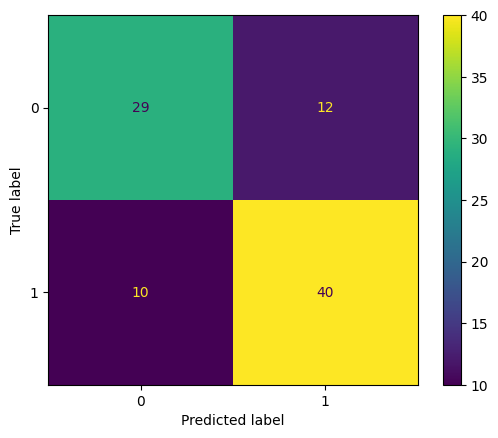

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predict_xgb)
plt.show()

### Stage 10: Hyperparameter Tunning(XGBOOST)

In [32]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.1,0.2]
}

gs = GridSearchCV(xgb,param_grid,cv=5,scoring='accuracy',verbose=2)
gs.fit(X_train_scaled,y_train)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.4s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=5, n_es

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [33]:
print("Best Param :",gs.best_params_)

Best Param : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}


In [34]:
best_xg = gs.best_estimator_
y_predict_bxgb = best_xg.predict(X_test_scaled)

In [36]:
print("==== XG Boost ===")
print()
print("Accuracy Score:",round(accuracy_score(y_test,y_predict_bxgb)*100,2),'%')
print()
print(classification_report(y_test,y_predict_bxgb))

==== XG Boost ===

Accuracy Score: 76.92 %

              precision    recall  f1-score   support

           0       0.78      0.68      0.73        41
           1       0.76      0.84      0.80        50

    accuracy                           0.77        91
   macro avg       0.77      0.76      0.76        91
weighted avg       0.77      0.77      0.77        91



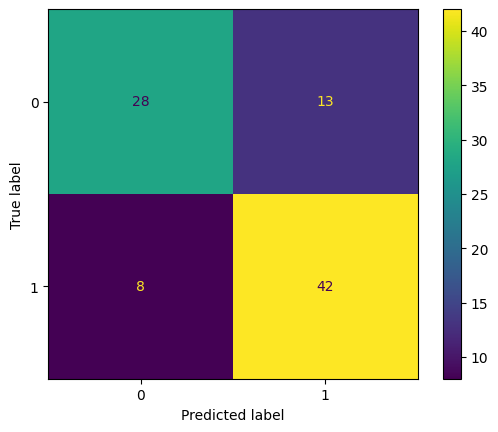

In [37]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predict_bxgb)
plt.show()

### Stage 11: Cross Validation

In [38]:
models ={
    "Logistic Regression ":lr,
    "KNN":knn,
    "Random Forest":rf,
    "XGBOOST":xgb,
    "XGBOOST(Tunned)":best_xg
}

In [39]:
for name,model in models.items():
    scores = cross_val_score(model,X_train_scaled,y_train,cv=5,scoring='accuracy')
    print(f'{name}:{scores.mean():.2f}')


Logistic Regression :0.84
KNN:0.84
Random Forest:0.84
XGBOOST:0.82
XGBOOST(Tunned):0.82


In [40]:
preds = {
    'Logistic Regression': y_predict_lr,
    'KNN': y_predict_knn,
    'Random Forest': y_predict_rf,
    'XGBoost': y_predict_xgb,
    'XGBoost (Tuned)': y_predict_bxgb
}

In [41]:
results = []
for name, pred in preds.items():
    results.append({
        'Model': name,
        'Accuracy (%)': round(accuracy_score(y_test, pred) * 100, 2),
        'Precision (%)': round(precision_score(y_test, pred) * 100, 2),
        'Recall (%)': round(recall_score(y_test, pred) * 100, 2),
        'F1-Score (%)': round(f1_score(y_test, pred) * 100, 2)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy (%)', ascending=False)
results_df

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
1,KNN,79.12,78.18,86.0,81.90
2,Random Forest,79.12,79.25,84.0,81.55
4,XGBoost (Tuned),76.92,76.36,84.0,80.00
0,Logistic Regression,75.82,75.93,82.0,78.85
3,XGBoost,75.82,76.92,80.0,78.43


In [42]:
with open('best_model.pkl','wb') as f:
    pickle.dump(knn,f)

print("Model Saved Succesfully")

Model Saved Succesfully


In [43]:
with open('sclaer.pkl','wb') as f:
    pickle.dump(scaler,f)
print("Scaler Saved Succefully")

Scaler Saved Succefully
